**Practica #2:**

**Introducción a Python y Señales y Sistemas Discretos**

**Presentado por:**
Karly Tarazona, Luis Montoya 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.stats as stats
from scipy.signal import find_peaks

Implementación de función  para calcular valor cuadrático medio (RMS).

In [3]:
def calcular_rms(x):
    x = np.array(x)
    return np.sqrt(np.mean(x**2))

**Procedimiento**

1. A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo.

In [4]:

# Cargar el archivo .mat
data = sio.loadmat(r"signals.mat")
print(data.keys())

ecg = data["ECG_asRecording"].flatten() 
ecg_filtered = data['ECG_filtered'].flatten()
fs = data['Fs'][0][0] # Frecuencia de muestreo en Hz

#Calcular el número de muestras
n_muestras = len(ecg)

# Crear el vector de tiempo
duracion = n_muestras / fs
tiempo = np.linspace(0, duracion, n_muestras, endpoint=False)

print(f"---Duración de la señal: {duracion} segundos---")

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
---Duración de la señal: 30.0 segundos---


2. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

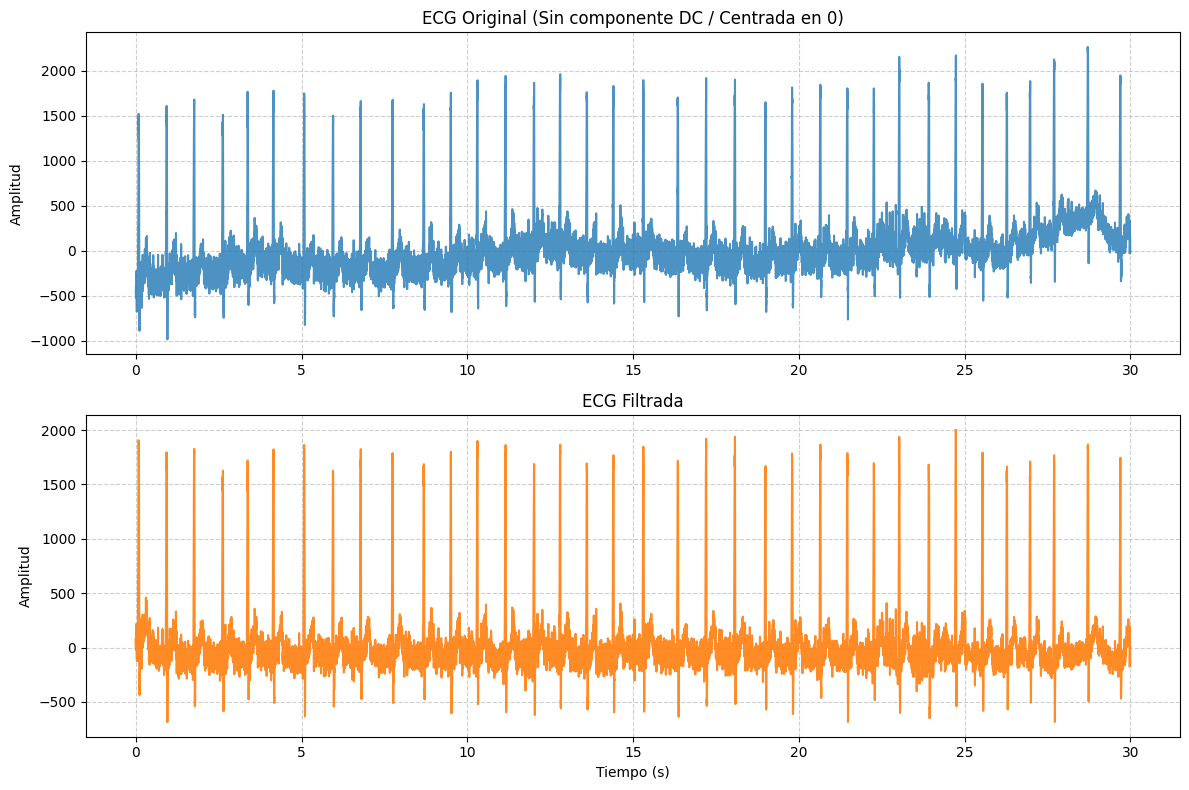

In [5]:
#Centrar ambos gráficos para poder analizar bien los datos y ver la diferencia entre la señal original y la filtrada
ecg_centrada = ecg - np.mean(ecg)

plt.figure(figsize=(12, 8))

#Señal Original (Centrada en 0)
plt.subplot(2, 1, 1)
plt.plot(tiempo, ecg_centrada, color="tab:blue", alpha=0.8)
plt.ylabel("Amplitud")
plt.title("ECG Original (Sin componente DC / Centrada en 0)")
plt.grid(True, linestyle="--", alpha=0.6)

#Señal Filtrada
plt.subplot(2, 1, 2)
plt.plot(tiempo, ecg_filtered, color="tab:orange", alpha=0.9)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG Filtrada")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()  
plt.show()


Se observó que la señal sin filtrar tiene una ondulación de baja frecuencia que no es muy grande y ocurre cada muchos ciclos de la señal. Para filtrar este ruido se usa un filtro pasa-altas que impide el paso de frecuencias bajas como la observada en la señal sin filtras y deja pasar las más altas a cierto umbral. En este caso es ideal debido a la alta frecuencia de la señal de ECG que se desea filtrar.


3. Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.Repita lo mismo con la señal filtrada y compare

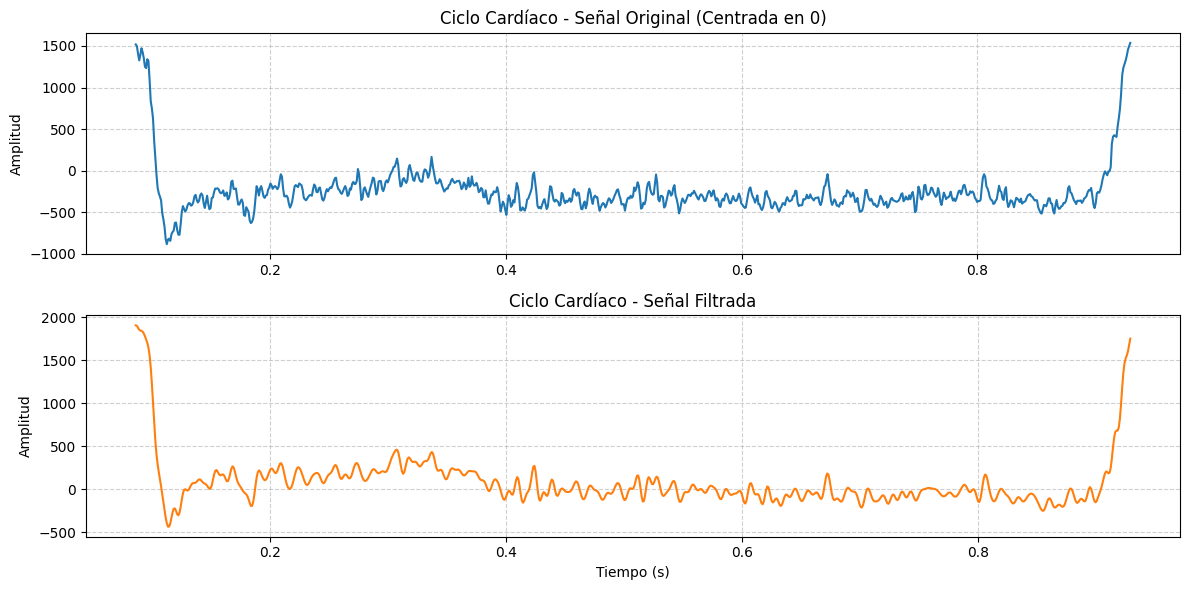


Métrica                | Señal Orig. (Centrada) | Señal Filtrada 
-----------------------------------------------------------------
Promedio               | -250.035625            | 74.009958      
Valor RMS              | 395.175956             | 319.627578     
Varianza               | 93754.608888           | 96796.347692   
Desviación Estándar    | 306.193744             | 311.121114     


In [6]:
# Detección de picos R (restar la media no altera la posición ni prominencia relativa de los picos)
picos_orig, _ = find_peaks(ecg, distance=int(fs * 0.6), prominence=np.std(ecg))
picos_filt, _ = find_peaks(ecg_filtered, distance=int(fs * 0.6), prominence=np.std(ecg_filtered))

# Selección del primer ciclo cardíaco completo
ciclo_orig = ecg_centrada[picos_orig[0]:picos_orig[1]]
tiempo_orig = tiempo[picos_orig[0]:picos_orig[1]]

ciclo_filt = ecg_filtered[picos_filt[0]:picos_filt[1]]
tiempo_filt = tiempo[picos_filt[0]:picos_filt[1]]

# Graficación del ciclo seleccionado
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(tiempo_orig, ciclo_orig, color="tab:blue", lw=1.5)
plt.title("Ciclo Cardíaco - Señal Original (Centrada en 0)")
plt.ylabel("Amplitud")
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(2, 1, 2)
plt.plot(tiempo_filt, ciclo_filt, color="tab:orange", lw=1.5)
plt.title("Ciclo Cardíaco - Señal Filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Cálculo de métricas estadísticas
def calcular_metricas(sig):
    return {
        "Promedio": np.mean(sig),
        "Valor RMS": calcular_rms(sig),
        "Varianza": np.var(sig, ddof=1),
        "Desviación Estándar": np.std(sig, ddof=1)
    }

metricas_orig = calcular_metricas(ciclo_orig)
metricas_filt = calcular_metricas(ciclo_filt)

# Impresión comparativa
print(f"\n{'Métrica':<22} | {'Señal Orig. (Centrada)':<22} | {'Señal Filtrada':<15}")
print("-" * 65)
for clave in metricas_orig:
    val_o = metricas_orig[clave]
    val_f = metricas_filt[clave]
    print(f"{clave:<22} | {val_o:<22.6f} | {val_f:<15.6f}")

Comparación: 
Con ayuda del promedio y el valor RMS de ambas señales se puede analizar el efecto del ruido de manera clara. Al tener el efecto de un ruido de alta frecuencia en toda la señal, la señal sin filtrar y centrada alrededor de 0 presenta un promedio muy alejado de la filtrada, esto pone en evidencia ese ruido de alta frecuencia que modificaba la amplitud de muchos valores. El valor RMS permite analizar el efecto que genera el ruido sobre la magnitud de la señal. Este aclara algunos aspectos del promedio porque ese dato depende mucho del eje sobre el cual se centre la señal. Para la señal sin filtro se obtuvo un valor RMS mayor, lo que representa un error y un problema a la hora de analizar el estado de un paciente. 

Por otro lado, se observa una varianza mayor de la señal filtrada, esto tiene sentido ya que el cálculo de esta depende del promedio y el valor RMS. Al tener una mayor diferencia en los promedios entre ambas señales, la varianza de la señal filtrada tiene un aumento.


4. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?

--- Resultados Estadísticos por Ciclo ---
Ciclo 1  -> Promedio: 74.0100 | Varianza: 96796.3477
Ciclo 2  -> Promedio: -1.4626 | Varianza: 104913.3148
Ciclo 3  -> Promedio: -10.4330 | Varianza: 82544.3112
Ciclo 4  -> Promedio: -20.9752 | Varianza: 46900.6500
Ciclo 5  -> Promedio: 40.8711 | Varianza: 114993.4034
Ciclo 6  -> Promedio: -27.9437 | Varianza: 58209.1865
Ciclo 7  -> Promedio: 0.4308 | Varianza: 77794.7894
Ciclo 8  -> Promedio: 21.4079 | Varianza: 100384.9082
Ciclo 9  -> Promedio: -10.1753 | Varianza: 71857.8339
Ciclo 10 -> Promedio: 8.8121 | Varianza: 68552.0982
Ciclo 11 -> Promedio: -8.9062 | Varianza: 76179.9473
Ciclo 12 -> Promedio: 13.2133 | Varianza: 93977.1626
Ciclo 13 -> Promedio: -4.2033 | Varianza: 88052.7145
Ciclo 14 -> Promedio: -14.9697 | Varianza: 77109.7576
Ciclo 15 -> Promedio: 27.1083 | Varianza: 89748.1477


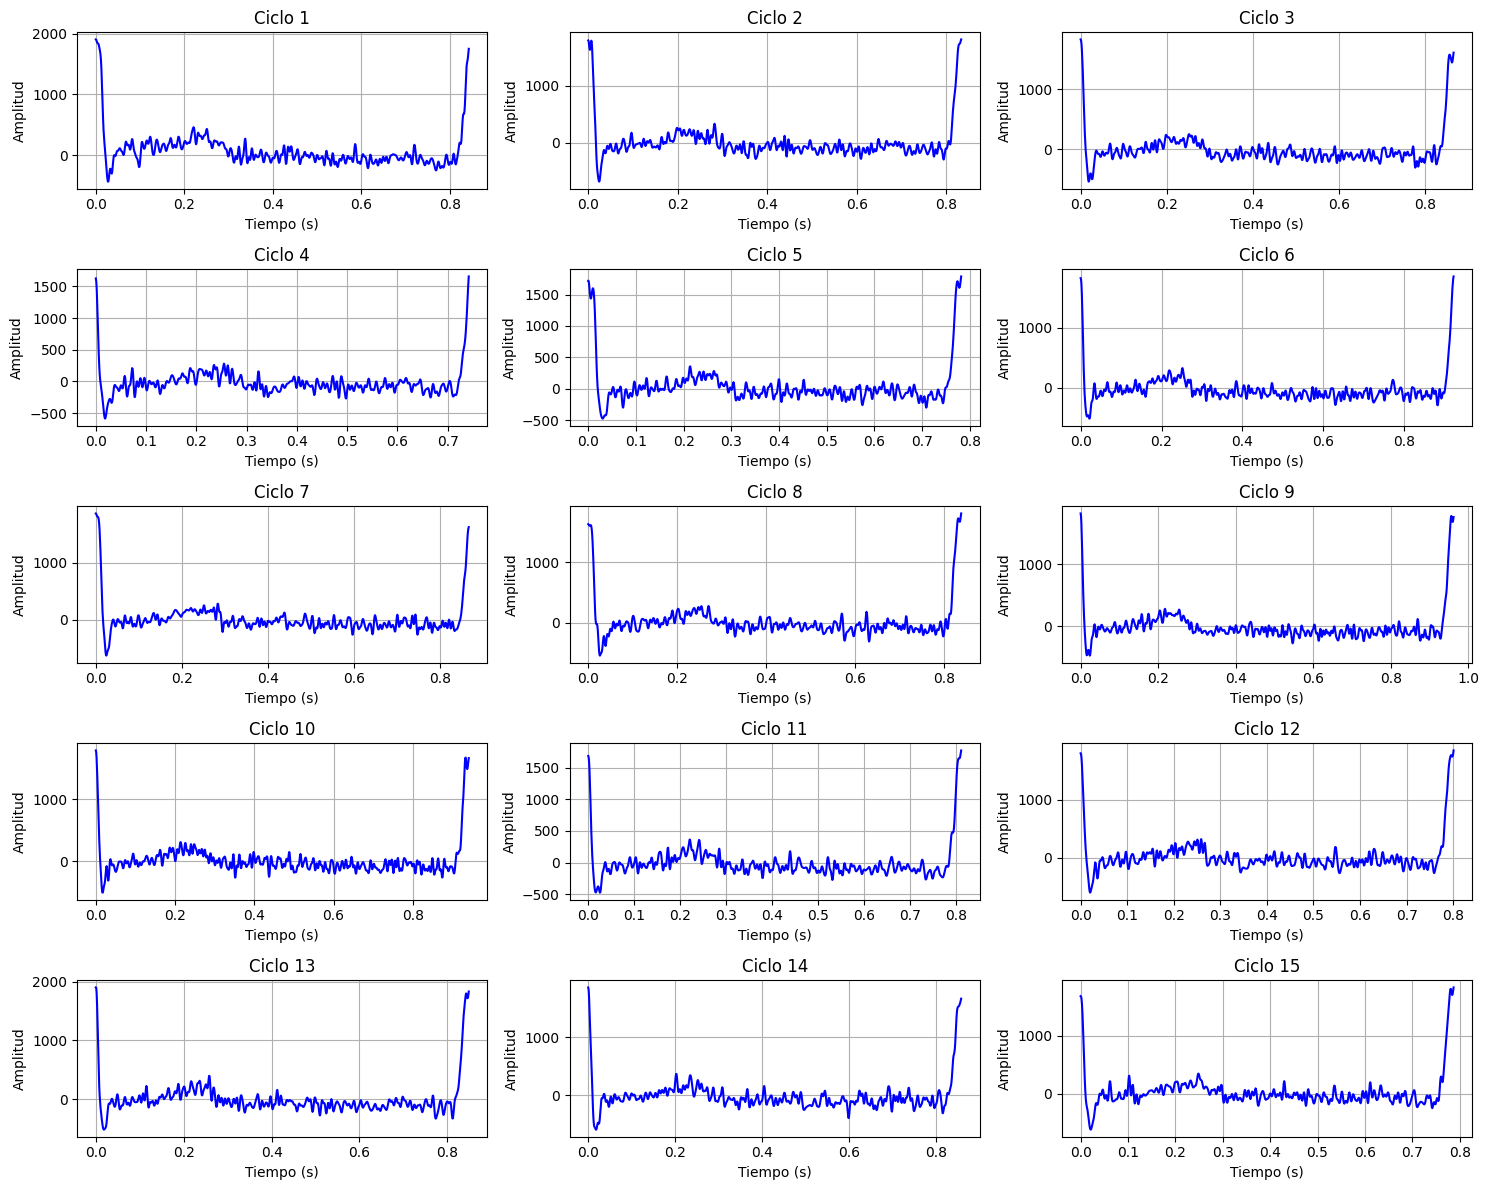

In [ ]:
picos_r, _ = find_peaks(ecg_filtered, distance=fs * 0.6)  # Asumiendo un mínimo de 0.6s entre latidos

ciclos = []
medias = []
varianzas = []

# Extraer los primeros 15 ciclos
for i in range(15):
    ciclo_actual = ecg_filtered[picos_r[i] : picos_r[i + 1]]
    ciclos.append(ciclo_actual)
    medias.append(np.mean(ciclo_actual))
    varianzas.append(np.var(ciclo_actual, ddof=1))

print("--- Resultados Estadísticos por Ciclo ---")
for i in range(15):
    print(f"Ciclo {i+1:<2} -> Promedio: {medias[i]:.4f} | Varianza: {varianzas[i]:.4f}")

# Creación de cuadrícula de 5x3 para los 15 ciclos
fig, axes = plt.subplots(5, 3, figsize=(15, 12))


axes = axes.flatten()

# Iterar sobre los 15 ciclos guardados
for i in range(15):
    ciclo_actual = ciclos[i]

    # Crear un vector de tiempo específico para la longitud de cada ciclo
    t_ciclo = np.linspace(0, len(ciclo_actual) / fs, len(ciclo_actual), endpoint=False)

    # Graficar en su respectivo recuadro
    axes[i].plot(t_ciclo, ciclo_actual, color="blue")
    axes[i].set_title(f"Ciclo {i+1}")
    axes[i].set_xlabel("Tiempo (s)")
    axes[i].set_ylabel("Amplitud")
    axes[i].grid(True)

# Ajustar automáticamente los espacios para que los textos no se superpongan
plt.tight_layout()
plt.show()

Como coclusion se observa que esta señal no es estacionaria debido a que para que se connsidere como estacionaria esta deberia mantener sus metricas estadisticas razonablemente constantes a lo largo del tiempo, lo cual no cumple ya que presenta una insetabilidad en cuanto a los promedios que reslutan muy fluctuantes de manera drastica entre ciclos pasando de valores muy negativos a unos muy positivos, por otro lado la varianza se duplica entre los segmentos, y como esta mide qué tan dispersos están los datos respecto a su promedio se puede concluir que hay fluctuaciones distintas de un ciclo respecto a otro.

5. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).

In [ ]:
import numpy as np
from scipy import stats

def evaluar_comparacion_ciclos(ciclo_1, ciclo_2, nombre_c1="Ciclo A", nombre_c2="Ciclo B"):
    print(f"--- COMPARACIÓN: {nombre_c1} vs {nombre_c2} ---")
    
    # 1. Prueba de Normalidad (Shapiro-Wilk)
    _, p_norm1 = stats.shapiro(ciclo_1)
    _, p_norm2 = stats.shapiro(ciclo_2)
    print(f"Normalidad ({nombre_c1}): p-valor = {p_norm1:.4f}")
    print(f"Normalidad ({nombre_c2}): p-valor = {p_norm2:.4f}")
    
    cumple_normalidad = (p_norm1 > 0.05) and (p_norm2 > 0.05)
    
    # 2. Prueba de Homocedasticidad (Levene)
    _, p_levene = stats.levene(ciclo_1, ciclo_2)
    print(f"Homocedasticidad (Levene): p-valor = {p_levene:.4f}")
    
    cumple_homocedasticidad = (p_levene > 0.05)
    
    # 3. Selección y ejecución de la prueba de hipótesis
    if cumple_normalidad and cumple_homocedasticidad:
        stat, p_val = stats.ttest_ind(ciclo_1, ciclo_2, equal_var=True)
        prueba = "Prueba t de Student (Paramétrica)"
    elif cumple_normalidad and not cumple_homocedasticidad:
        stat, p_val = stats.ttest_ind(ciclo_1, ciclo_2, equal_var=False) # t de Welch
        prueba = "Prueba t de Welch (Sin homocedasticidad)"
    else:
        stat, p_val = stats.mannwhitneyu(ciclo_1, ciclo_2)
        prueba = "Prueba U de Mann-Whitney (No paramétrica)"
        
    print(f"\nMétodo aplicado: {prueba}")
    print(f"Estadístico = {stat:.4f} | p-valor = {p_val:.4e}")
    
    if p_val < 0.05:
        print("Resultado: EXISTE diferencia estadística significativa entre los ciclos (p < 0.05).\n")
    else:
        print("Resultado: NO existe diferencia estadística significativa entre los ciclos (p >= 0.05).\n")


evaluar_comparacion_ciclos(ciclos[0], ciclos[1], "Ciclo 1", "Ciclo 2")


--- COMPARACIÓN: Ciclo 1 vs Ciclo 2 ---
Normalidad (Ciclo 1): p-valor = 0.0000
Normalidad (Ciclo 2): p-valor = 0.0000
Homocedasticidad (Levene): p-valor = 0.2240

Método aplicado: Prueba U de Mann-Whitney (No paramétrica)
Estadístico = 478150.0000 | p-valor = 2.3126e-26
Resultado: EXISTE diferencia estadística significativa entre los ciclos (p < 0.05).



Se observo que los dos ciclos estudiados no cumplian con los requisitos para realizar una prueba t, por lo que se procedio a realizar un prueba u de mann-whinwy para datos no parametricos, de este se obtuvo un valor p=2.31 menor a 0.05, lo que significa que la distribución de la señal (su media o mediana) varía sustancialmente en función del tiempo. Esto demuestra formalmente que la señal es no estacionaria, ya que una condición indispensable para la estacionariedad es que los parámetros estadísticos permanezcan invariantes temporalmente.

6. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad)

In [15]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(ecg)

estadistico_adf = resultado_adf[0]
p_valor = resultado_adf[1]
valores_criticos = resultado_adf[4]

print("--- PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) ---")
print(f"Estadístico ADF: {estadistico_adf:.4f}")
print(f"p-valor: {p_valor:.4e}")
print("Valores Críticos:")
for nivel, valor in valores_criticos.items():
    print(f"   {nivel}: {valor:.4f}")

if p_valor < 0.05:
    print("\nResultado: Se rechaza H0. La señal ES ESTACIONARIA.")
else:
    print("\nResultado: No se rechaza H0. La señal NO ES ESTACIONARIA.")

--- PRUEBA DE DICKEY-FULLER AUMENTADA (ADF) ---
Estadístico ADF: -16.4432
p-valor: 2.4170e-29
Valores Críticos:
   1%: -3.4306
   5%: -2.8616
   10%: -2.5668

Resultado: Se rechaza H0. La señal ES ESTACIONARIA.


C:\Users\Acer\AppData\Local\Temp\ipykernel_27396\2383560042.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(ecg)


El resultado rechazo H0, y dio que la señal era estacionaria, sin embargo comprando con lo anteriormente hecho esto no concuerda ya que el enfoque de Dickey-Fuller evalúa si la señal explota hacia el infinito o sigue una tendencia aleatoria. Como el ECG es una señal oscilatoria que regresa constantemente a su eje central (mean-reverting), el ADF concluye que no hay raíz unitaria y la declara estacionaria globalmente.sin embargo; el enfoque por ciclos evalúa la media y varianza donde en cada ciclo obtuvo métricas distintas, rompiendo la condición WSS (estacionariedad estricta en sentido amplio ) a nivel local donde esto puede deberse a la variabilidad fisiológica y a la deriva de la línea base.